In [2]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# Thiết lập hiển thị biểu đồ
sns.set_theme(style="whitegrid") # thiết lập theme cho seaborn
plt.rcParams['font.sans-serif'] = 'DejaVu Sans' # Thiết lập font chữ cho matplotlib
plt.rcParams['figure.figsize'] = (10, 5) # thiết lập kích thước mặc định cho biểu đồ

# Danh sách class theo yêu cầu
CLASSES = [
    'dent',
    'scratch',
    'crack',
    'glass_shatter',
    'lamp_broken',
    'tire_flat'
]
CLASS_MAP = {i: name for i, name in enumerate(CLASSES)}
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# Đường dẫn dataset (chỉnh lại phù hợp với cấu trúc thư mục của bạn)
DATA_DIR = BASE_DIR / "data" / "CarDD_COCO"
ANNOTATIONS_DIR = DATA_DIR / "annotations"

TRAIN_JSON = ANNOTATIONS_DIR / "instances_train2017.json"
VAL_JSON   = ANNOTATIONS_DIR / "instances_val2017.json"
TEST_JSON  = ANNOTATIONS_DIR / "instances_test2017.json"

print("Đường dẫn train JSON:", TRAIN_JSON)
print("File tồn tại:", TRAIN_JSON.exists())

Đường dẫn train JSON: c:\code\vehicle-damage-detection-assessment\data\CarDD_COCO\annotations\instances_train2017.json
File tồn tại: True


In [3]:
import json

# Đọc file annotations train
with open(TRAIN_JSON, 'r', encoding='utf-8') as f: #mở file JSON với encoding UTF-8 để tránh lỗi ký tự
    coco_train = json.load(f) 

# 1. Bảng Categories
categories = {cat["id"] : cat["name"] for cat in coco_train['categories']}

# 2. Bảng Images
df_images = pd.DataFrame(coco_train['images']) 
# Giữ các trường cơ bản: id, file_name, width, height
df_images = df_images[['id', 'file_name', 'width', 'height']].rename(columns={'id': 'image_id'})
df_images['aspect_ratio'] = df_images['width'] / df_images['height']

# 3. Bảng Annotations
df_annotations = pd.DataFrame(coco_train['annotations'])

# COCO format bbox: [x_min, y_min, width, height]
df_annotations['box_x'] = df_annotations['bbox'].apply(lambda b: b[0]) 
df_annotations['box_y'] = df_annotations['bbox'].apply(lambda b: b[1])
df_annotations['box_w'] = df_annotations['bbox'].apply(lambda b: b[2])
df_annotations['box_h'] = df_annotations['bbox'].apply(lambda b: b[3])
df_annotations['class_name'] = df_annotations['category_id'].map(categories)

# Tính tỷ lệ khung hình box và diện tích
df_annotations['box_aspect_ratio'] = df_annotations['box_w'] / (df_annotations['box_h'] + 1e-6)

# Merge thông tin kích thước ảnh vào bảng annotation để tính kích thước chuẩn hóa (normalized)
df_merged = df_annotations.merge(df_images, on='image_id', how='left')
df_merged['norm_w'] = df_merged['box_w'] / df_merged['width']
df_merged['norm_h'] = df_merged['box_h'] / df_merged['height']

print(f"Danh mục nhãn ({len(categories)} classes): {categories}")
print(f"Tổng số ảnh trong train: {len(df_images)}")
print(f"Tổng số box trong train: {len(df_annotations)}")

Danh mục nhãn (6 classes): {1: 'dent', 2: 'scratch', 3: 'crack', 4: 'glass shatter', 5: 'lamp broken', 6: 'tire flat'}
Tổng số ảnh trong train: 2816
Tổng số box trong train: 6211


In [4]:
total_images = len(df_images)
total_boxes = len(df_annotations)

# Tập hợp ID ảnh có ít nhất 1 nhãn
images_with_ann = set(df_annotations['image_id'].unique())
bg_images_count = total_images - len(images_with_ann)

print("=" * 45)
print("             TỔNG QUAN TẬP TRAIN (CarDD)")
print("=" * 45)
print(f"Tổng số ảnh:                 {total_images}")
print(f"Tổng số annotation (boxes):  {total_boxes}")
print(f"Số ảnh không có nhãn (bg):   {bg_images_count} ({bg_images_count / total_images * 100:.2f}%)")
print(f"Số box trung bình mỗi ảnh:   {total_boxes / total_images:.2f}")
print("=" * 45)

             TỔNG QUAN TẬP TRAIN (CarDD)
Tổng số ảnh:                 2816
Tổng số annotation (boxes):  6211
Số ảnh không có nhãn (bg):   0 (0.00%)
Số box trung bình mỗi ảnh:   2.21


Số lượng box chi tiết theo từng nhãn:


,class_name,total_boxes
0,scratch,2560
1,dent,1806
2,crack,651
3,lamp broken,494
4,glass shatter,475
5,tire flat,225


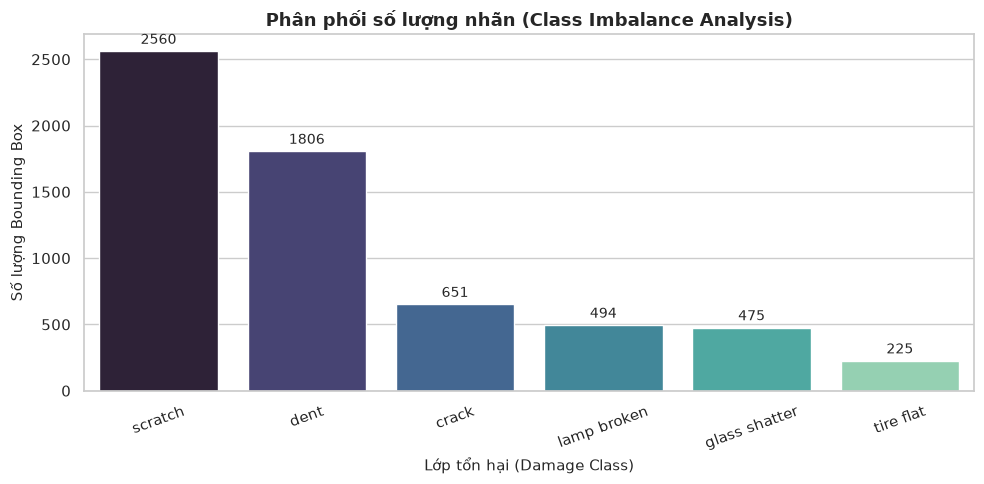

In [5]:
class_counts = df_annotations['class_name'].value_counts()

print("Số lượng box chi tiết theo từng nhãn:")
display(class_counts.reset_index().rename(columns={'index': 'class_name', 'count': 'total_boxes'}))

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="mako", legend=False)
plt.title("Phân phối số lượng nhãn (Class Imbalance Analysis)", fontsize=13, fontweight='bold')
plt.xlabel("Lớp tổn hại (Damage Class)", fontsize=11)
plt.ylabel("Số lượng Bounding Box", fontsize=11)
plt.xticks(rotation=20)

# Ghi số lượng cụ thể trên đầu mỗi cột
for p in ax.patches:
    val = int(p.get_height())
    ax.annotate(f'{val}', (p.get_x() + p.get_width() / 2., val),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.show()

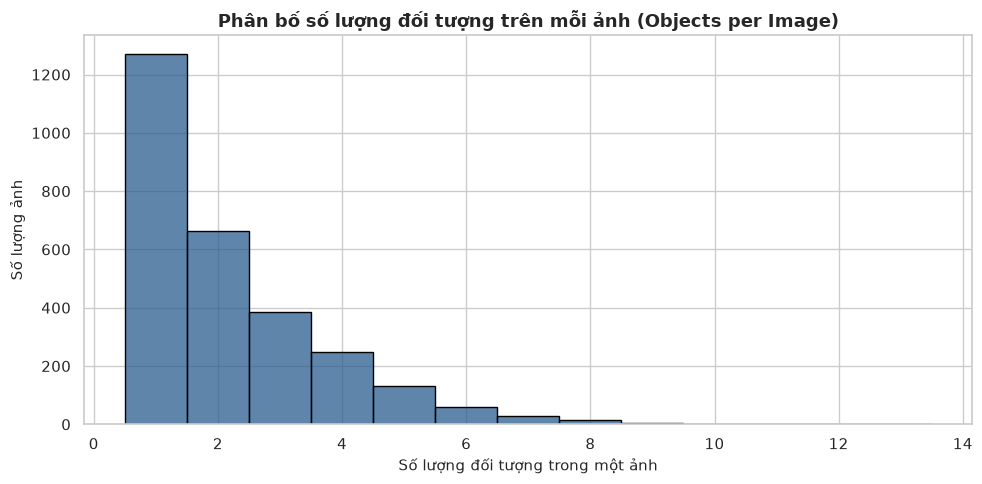

Thống kê chi tiết số lượng box / ảnh:
count    2816.000000
mean        2.205611
std         1.551479
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        13.000000
Name: image_id, dtype: float64


In [6]:
# Đếm số box của từng ảnh
boxes_per_img = df_annotations['image_id'].value_counts()

# Ghép với toàn bộ danh sách ảnh để tính cả ảnh 0 box
all_img_box_counts = df_images['image_id'].map(boxes_per_img).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(all_img_box_counts, discrete=True, color="#2b5c8f", edgecolor="black", ax=ax)
plt.title("Phân bố số lượng đối tượng trên mỗi ảnh (Objects per Image)", fontsize=13, fontweight='bold')
plt.xlabel("Số lượng đối tượng trong một ảnh", fontsize=11)
plt.ylabel("Số lượng ảnh", fontsize=11)

plt.tight_layout()
plt.show()

print("Thống kê chi tiết số lượng box / ảnh:")
print(all_img_box_counts.describe())

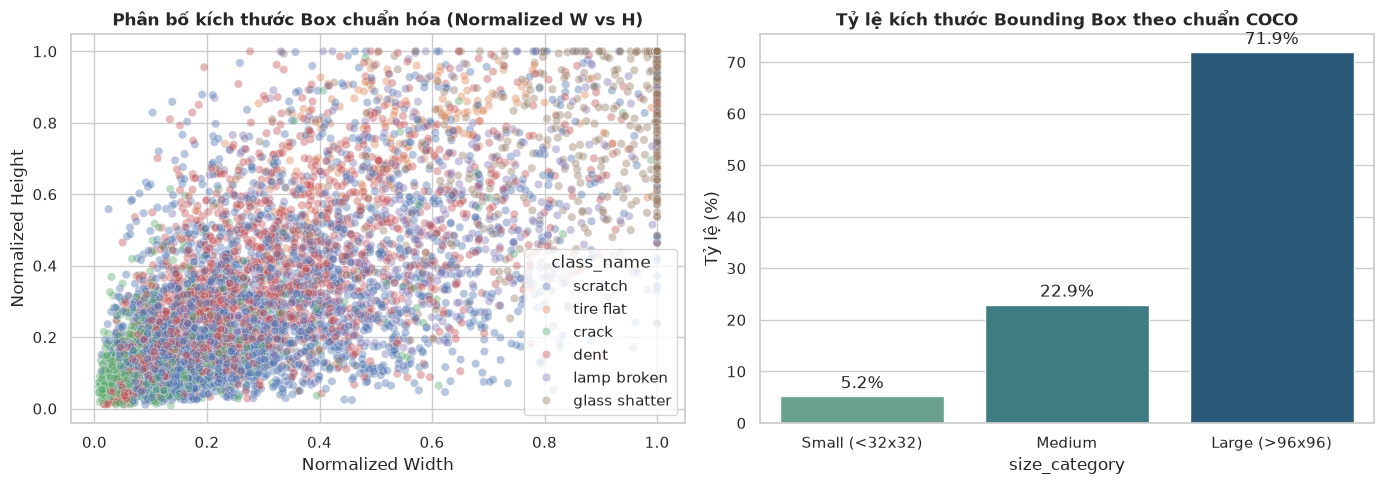

In [7]:
# Phân loại kích thước theo chuẩn COCO:
# Small: area < 32^2 (1024 px^2)
# Medium: 32^2 <= area <= 96^2 (9216 px^2)
# Large: area > 96^2
def coco_size_category(area):
    if area < 32 * 32:
        return 'Small (<32x32)'
    elif area <= 96 * 96:
        return 'Medium'
    else:
        return 'Large (>96x96)'

# COCO có sẵn trường 'area' trong annotations
df_merged['size_category'] = df_merged['area'].apply(coco_size_category)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Phân bố normalized w vs h
sns.scatterplot(
    data=df_merged,
    x="norm_w",
    y="norm_h",
    hue="class_name",
    alpha=0.4,
    ax=axes[0]
)
axes[0].set_title("Phân bố kích thước Box chuẩn hóa (Normalized W vs H)", fontweight='bold')
axes[0].set_xlabel("Normalized Width")
axes[0].set_ylabel("Normalized Height")

# 2. Tỷ lệ phân loại Small / Medium / Large
size_dist = df_merged["size_category"].value_counts(normalize=True)[['Small (<32x32)', 'Medium', 'Large (>96x96)']] * 100
sns.barplot(x=size_dist.index, y=size_dist.values, ax=axes[1], palette="crest", hue=size_dist.index, legend=False)
axes[1].set_title("Tỷ lệ kích thước Bounding Box theo chuẩn COCO", fontweight='bold')
axes[1].set_ylabel("Tỷ lệ (%)")

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

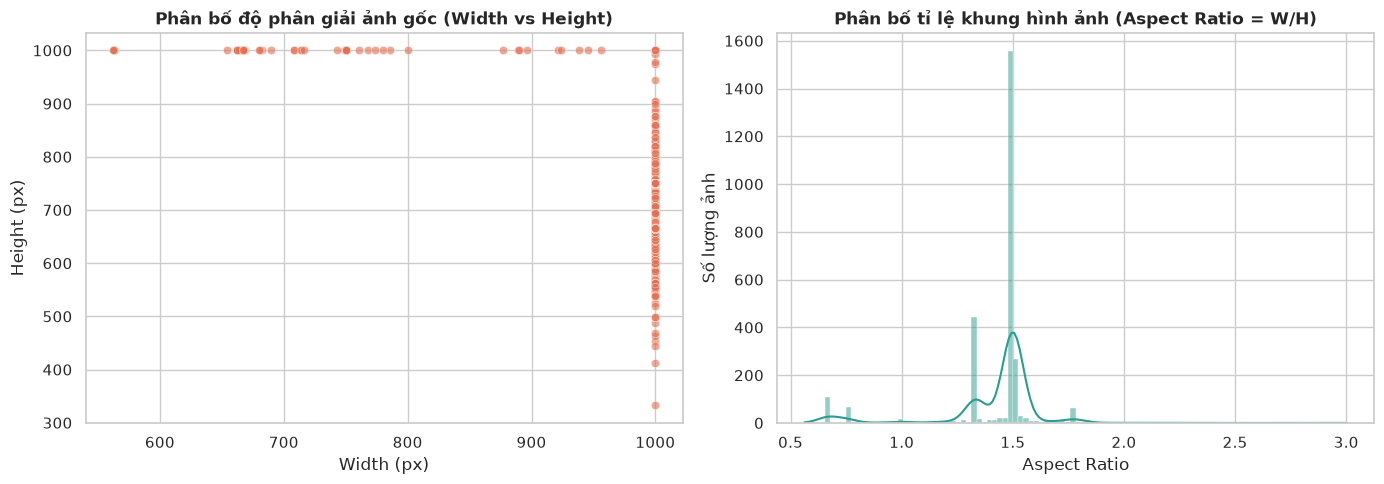

Thống kê kích thước ảnh gốc:
             width       height  aspect_ratio
count  2816.000000  2816.000000   2816.000000
mean    978.997514   705.300781      1.418905
std      77.448657    97.174243      0.227012
min     562.000000   333.000000      0.562000
25%    1000.000000   667.000000      1.333333
50%    1000.000000   667.000000      1.499250
75%    1000.000000   750.000000      1.499250
max    1000.000000  1000.000000      3.003003


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter kích thước ảnh (Width vs Height)
sns.scatterplot(
    data=df_images,
    x="width",
    y="height",
    color="#e76f51",
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title("Phân bố độ phân giải ảnh gốc (Width vs Height)", fontweight='bold')
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")

# 2. Tỉ lệ khung hình ảnh (Aspect Ratio = Width / Height)
sns.histplot(df_images["aspect_ratio"], kde=True, color="#2a9d8f", ax=axes[1])
axes[1].set_title("Phân bố tỉ lệ khung hình ảnh (Aspect Ratio = W/H)", fontweight='bold')
axes[1].set_xlabel("Aspect Ratio")
axes[1].set_ylabel("Số lượng ảnh")

plt.tight_layout()
plt.show()

print("Thống kê kích thước ảnh gốc:")
print(df_images[["width", "height", "aspect_ratio"]].describe())